# Sensitivity to initial residual concentration

In [ ]:
from functools import partial
from lucifex.fdm import AB, CN
from lucifex.sim import parallel_run, as_grid_simulation
from lucifex.plt import (
    plot_colormap, plot_line, set_ipynb_variable, 
    save_figure, get_ipynb_file_name
)
from lucifex.utils.npy_utils import as_index
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE

NX = 60
NY = 60
CELL_TYPE = 'quadrilateral'
COURANT_ADV = 0.75
COURANT_DIFF = 0.75
COURANT_REAC = 0.1
C_SEED = (1234, 5678)
c_ampl_opts = (1e-6, 1e-3)
c_freq_opts = ((8, 8), (16, 16), (48, 48))

n_proc = set_ipynb_variable('N_PROC', 3)
n_stop = set_ipynb_variable('N_STOP', 200)
dt_init = 1e-6
n_init = 10

STORE = 1
create_sim = dns_system_a(store_delta=STORE)

simulations = parallel_run(
    create_sim, n_proc, n_stop, 
    dt_init=dt_init, n_init=n_init,
    serialize=partial(as_grid_simulation,  slc_func='::5', include=('c', 'cMinMax', 'uRMS', 'uMinMax')),
    link=False,
)(
    Nx=NX,
    Ny=NY,
    cell=CELL_TYPE,
    scaling='advective',
    **SYSTEM_A_REFERENCE,
    dt_Cu=COURANT_ADV,
    courant_diff=COURANT_DIFF,
    dt_Cr=COURANT_REAC,
    c_stabilization=None,
    c_limits=None,
    diagnostic=True,
)(
    c_ampl=c_ampl_opts,
    c_freq=c_freq_opts,
)

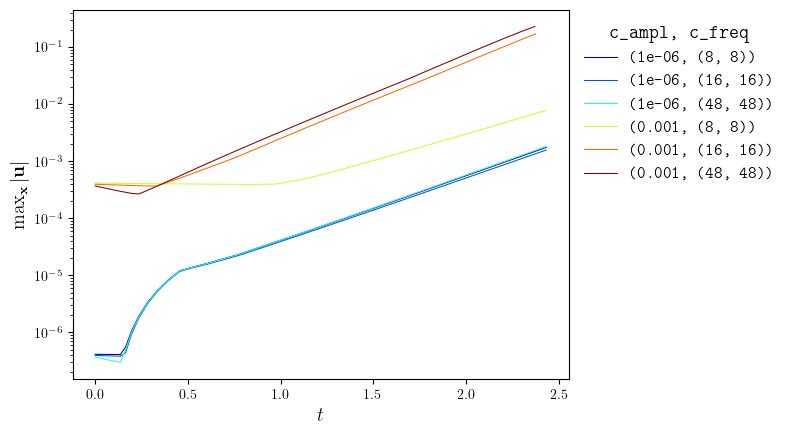

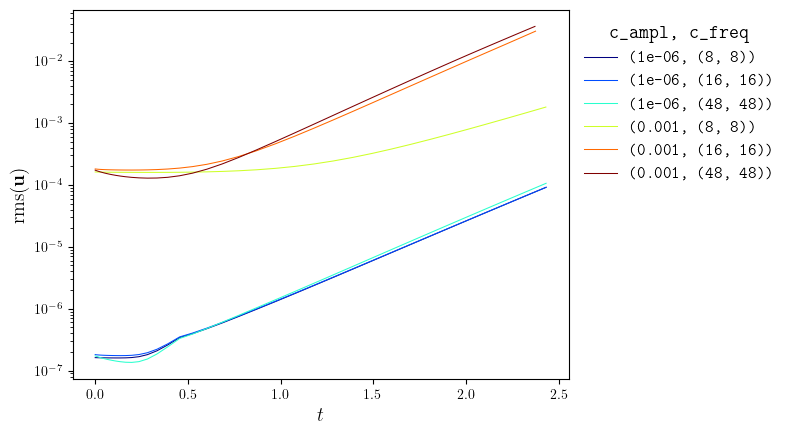

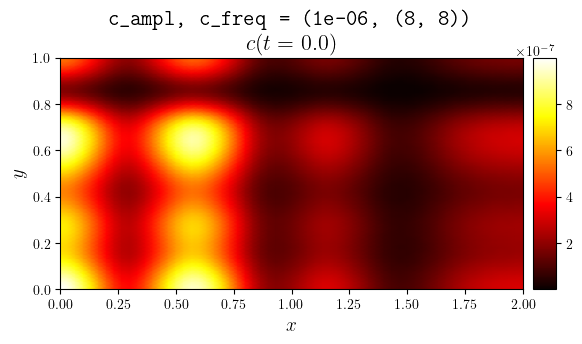

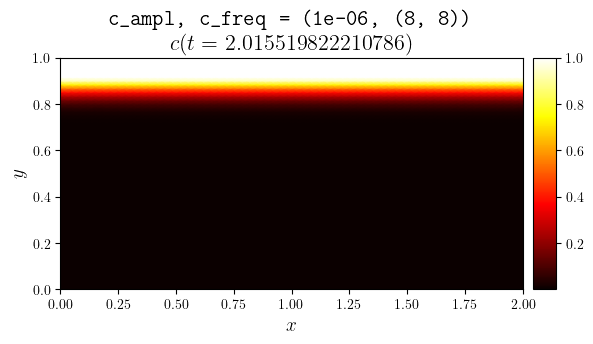

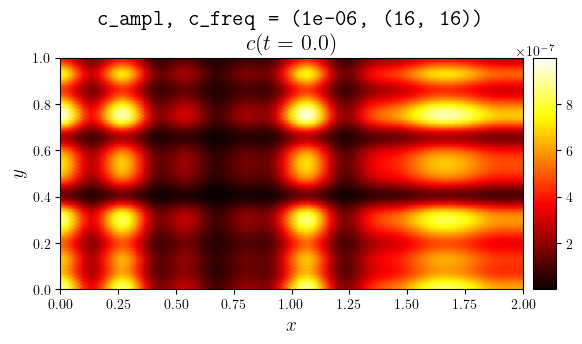

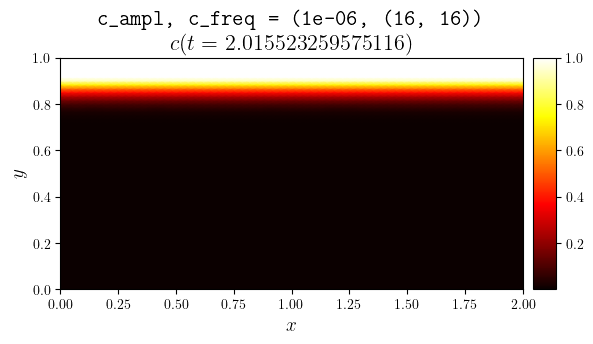

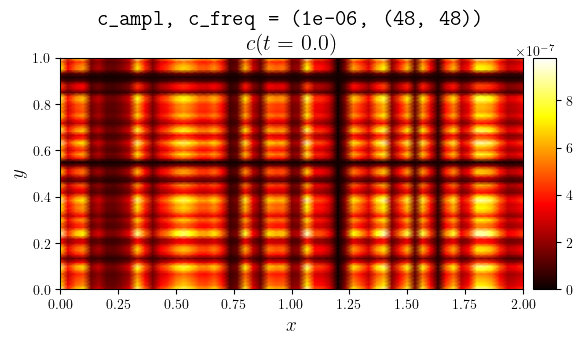

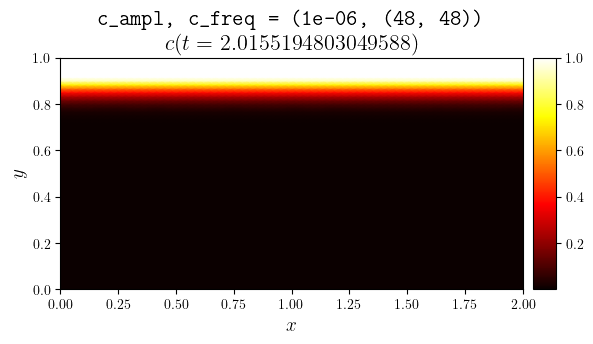

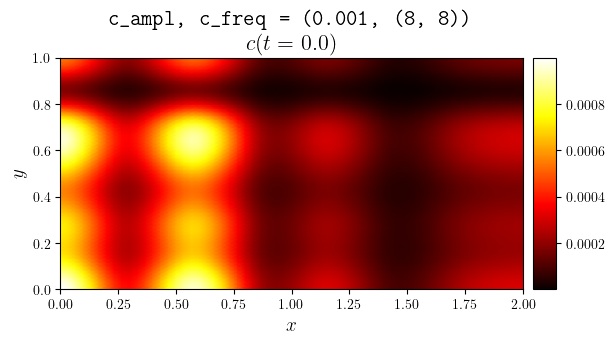

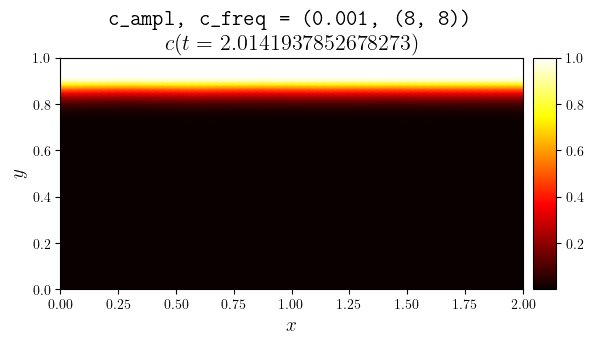

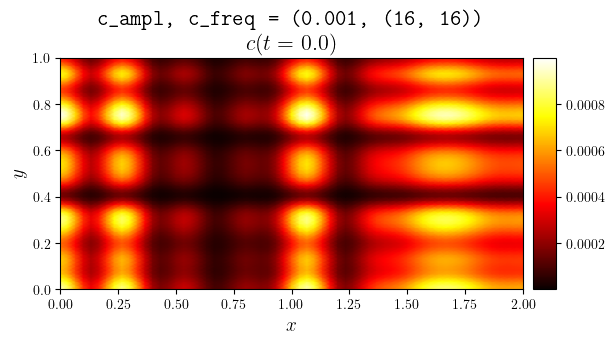

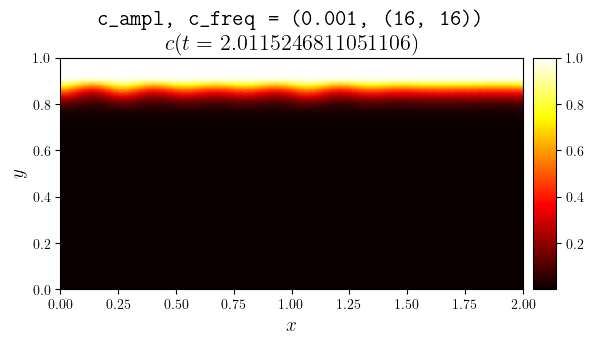

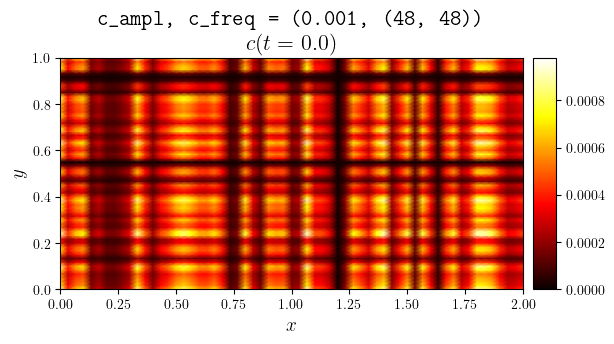

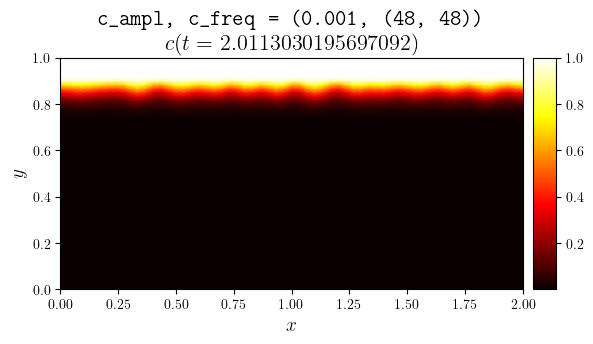

: 

In [ ]:
DIR_FIGS = f'./figures/{get_ipynb_file_name()}'

uMax_lines, uRMS_lines, labels = [], [], []
legend_title = f'$\\texttt{{c_ampl,~c_freq}}$'

t_target = 2.0
cmap_funcs, cmap_titles, cmap_names = [], [], []

for (c_ampl, c_freq), sim in simulations.items():
    label = f'\\texttt{{({c_ampl}, {c_freq})}}'
    labels.append(label)
    uMinMax = sim['uMinMax']
    uMax = uMinMax.sub(1)
    uMax_lines.append((uMax.time_series, uMax.value_series))
    uRMS = sim['uRMS']
    uRMS_lines.append((uRMS.time_series, uRMS.value_series))
    c = sim['c']
    time_index = as_index(c.time_series, t_target)
    for i in (0, time_index):
        cmap_funcs.append(c.series[i])
        t = c.time_series[i]
        cmap_titles.append(f'{legend_title}\\texttt{{ = }}{label}\n$c(t={t})$')
        cmap_names.append(f'c(x,y,t={t:.4f})__|c_ampl={c_ampl}|c_freq={c_freq}')

line_kws = dict(
    cyc='jet',
    x_label='$t$',
    legend_labels=labels,
    legend_title=legend_title,
)

fig, ax = plot_line(
    uMax_lines,
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
    **line_kws,
)
ax.set_yscale('log')
save_figure('uMax(t)', DIR_FIGS, prefix=False)(fig)

fig, ax = plot_line(
    uRMS_lines,
    y_label='$\mathrm{rms}(\mathbf{u})$',
    **line_kws,
)
ax.set_yscale('log')
save_figure('uRMS(t)', DIR_FIGS, prefix=False)(fig)

for func, title, name in zip(cmap_funcs, cmap_titles, cmap_names): 
    fig, ax = plot_colormap(func, title=title)
    save_figure(name, DIR_FIGS, prefix=False)(fig)